# 05 · Prototipo de bot de cobranza

Proyecto de titulación · **Maestría en Inteligencia Artificial Aplicada (UDLA)**
Amapola Technologies Corp.

Prototipo funcional que integra el modelo en el flujo del chatbot.

**Entrada:** cédula y mes.
**Salida:** JSON con score de probabilidad de cumplimiento, nivel de riesgo, acción sugerida y
respuesta diferenciada para el bot.

### Arquitectura

```
cédula + mes
     │
     ▼
[normalización]  zfill(10) y YYYYMM: mismas reglas del pipeline
     │
     ▼
[SHA-256 + salt] la cédula se convierte en id_anonimo
     │
     ▼
[tabla de scores pre-calculada]  outputs/scores_clientemes.csv
     │                            indexada por (id_anonimo, mes): sin datos personales
     ▼
[clasificación de riesgo]  alto < 0,35 ≤ medio ≤ 0,65 < bajo
     │
     ▼
JSON: score · nivel · acción sugerida · respuesta del bot
```

El scoring está desacoplado de la consulta de manera deliberada, dado que el bot no ejecuta el
modelo en línea sino que consulta una tabla recalculada por lote al inicio de cada mes. Esto aporta
tres ventajas:

- La respuesta se entrega en milisegundos.
- El comportamiento resulta reproducible y auditable, ya que el score asignado a cada cliente queda
  registrado.
- No es necesario cargar XGBoost dentro del servicio del chatbot.

Así también, la tabla no contiene datos personales, puesto que se indexa por el hash de la cédula y
no por la cédula. El motor calcula el hash del documento recibido y busca por dicho valor, de modo
que la cédula únicamente existe en memoria durante la consulta. Por ende, si la tabla llegara a
filtrarse no identificaría a ninguna persona sin conocer el salt.

## 0 · Configuración

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_OUTPUTS = RAIZ / "outputs"
DIR_FIGURAS = DIR_OUTPUTS / "figuras"
DIR_MODELOS = RAIZ / "modelos"
DIR_PROTOTIPO = RAIZ / "prototipo"
sys.path.insert(0, str(DIR_PROTOTIPO))

AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
ROJO, AMARILLO = "#d03b3b", "#fab219"
SUPERFICIE, TINTA, TINTA_2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, REJILLA, EJE = "#898781", "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.edgecolor": EJE,
    "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, rejilla="y"):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.grid(axis=rejilla, color=REJILLA, linewidth=0.8)
    ax.grid(axis="x" if rejilla == "y" else "y", visible=False)
    ax.tick_params(length=0)
    return ax

def titulos(ax, titulo, subtitulo=None):
    if subtitulo:
        ax.text(0, 1.13, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    else:
        ax.text(0, 1.035, titulo, transform=ax.transAxes, fontsize=12,
                fontweight="600", color=TINTA, va="bottom")

print("Prototipo en:", DIR_PROTOTIPO)

Prototipo en: C:\mia_capstone\prototipo


---
## 1 · Generación de la tabla de scores

In [2]:
paquete = joblib.load(DIR_MODELOS / "xgboost_cumplimiento_v1.pkl")
FEATURES = paquete["features"]
MES_CORTE = paquete["mes_corte"]
CATEGORICAS = ["ultima_intencion_antes_compromiso", "tipo_operacion", "bucket"]

df = pd.read_csv(DIR_OUTPUTS / "dataset_modelado_v1.csv",
                 dtype={"mes": str, "id_anonimo": str})

X = df[FEATURES].copy()
for c in FEATURES:
    X[c] = X[c].astype("category") if c in CATEGORICAS else pd.to_numeric(X[c], errors="coerce")

df["score"] = paquete["modelo"].predict_proba(X)[:, 1]
df["periodo"] = np.where(df["mes"] < MES_CORTE, "entrenamiento", "prueba")

print(f"Cliente-mes puntuados: {len(df):,}")
print(f"Modelo: XGBoost operativo | features: {len(FEATURES)}")
print(f"\nscore  min {df['score'].min():.3f} | media {df['score'].mean():.3f} | "
      f"mediana {df['score'].median():.3f} | max {df['score'].max():.3f}")
print(f"tasa real de cumplimiento: {df['cumplimiento_conciliado'].mean():.3f}")
print(f"\nPor periodo:\n{df.groupby('periodo')['score'].agg(['size', 'mean']).round(3).to_string()}")

Cliente-mes puntuados: 18,580
Modelo: XGBoost operativo | features: 13

score  min 0.014 | media 0.391 | mediana 0.413 | max 0.981
tasa real de cumplimiento: 0.205

Por periodo:
                size   mean
periodo                    
entrenamiento  11078  0.423
prueba          7502  0.345


> **Los scores del período de entrenamiento son en muestra.** El modelo vio esas filas al
> entrenarse, así que sus scores son optimistas y no sirven para medir desempeño. Se incluyen en la
> tabla porque el prototipo debe poder responder sobre cualquier cliente-mes histórico, pero la
> columna `periodo` los marca. Las métricas del notebook 03 se calcularon solo sobre `prueba`.

---
## 2 · Validación de los cortes de riesgo

Los cortes son **alto < 0,35 ≤ medio ≤ 0,65 < bajo** sobre el score, que es la probabilidad de
*cumplimiento*: score bajo significa poca probabilidad de pago, es decir riesgo alto.

Un corte solo sirve si los grupos que produce se comportan distinto. Se contrasta contra el
resultado real.

In [3]:
CORTE_ALTO, CORTE_BAJO = 0.35, 0.65

df["nivel_riesgo"] = np.where(df["score"] < CORTE_ALTO, "alto",
                       np.where(df["score"] <= CORTE_BAJO, "medio", "bajo"))

orden = ["alto", "medio", "bajo"]
resumen = (df.groupby("nivel_riesgo")
             .agg(n=("score", "size"),
                  score_medio=("score", "mean"),
                  cumplimiento_real=("cumplimiento_conciliado", "mean"),
                  mora_media=("dias_mora_inicial", "mean"))
             .reindex(orden))
resumen["pct_cartera"] = resumen["n"] / len(df)
display(resumen.round(4))

print("Separacion entre extremos: "
      f"{resumen.loc['bajo','cumplimiento_real'] / resumen.loc['alto','cumplimiento_real']:.1f}x")
print("\nSolo sobre el periodo de prueba (fuera de muestra):")
prueba = df[df["periodo"] == "prueba"]
display(prueba.groupby("nivel_riesgo")
        .agg(n=("score", "size"), cumplimiento_real=("cumplimiento_conciliado", "mean"))
        .reindex(orden).round(4))

,n,score_medio,cumplimiento_real,mora_media,pct_cartera
nivel_riesgo,,,,,
alto,8074,0.1387,0.0477,70.5947,0.4346
medio,7237,0.5020,0.2453,28.7969,0.3895
bajo,3269,0.7699,0.5038,21.2059,0.1759


Separacion entre extremos: 10.6x

Solo sobre el periodo de prueba (fuera de muestra):


,n,cumplimiento_real
nivel_riesgo,,
alto,3747,0.0534
medio,2680,0.2623
bajo,1075,0.3637


figura -> outputs/figuras/27_niveles_riesgo_prototipo.png


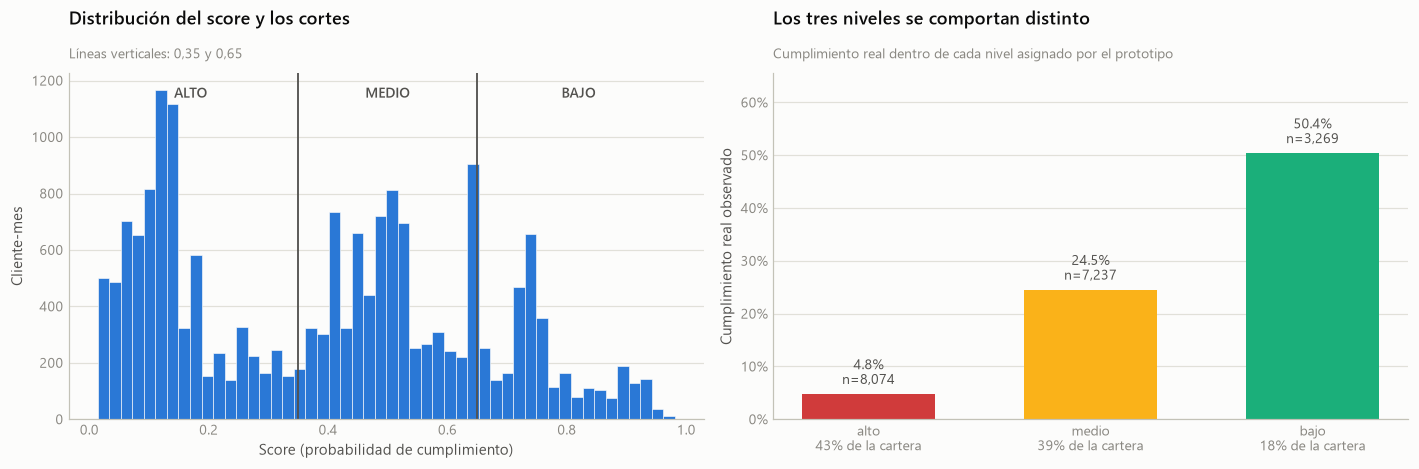

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
COLOR_NIVEL = {"alto": ROJO, "medio": AMARILLO, "bajo": AQUA}

ax = axes[0]
ax.hist(df["score"], bins=50, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.4)
for corte in (CORTE_ALTO, CORTE_BAJO):
    ax.axvline(corte, color=TINTA_2, linewidth=1.2)
ymax = ax.get_ylim()[1]
for x, txt in [(0.17, "ALTO"), (0.50, "MEDIO"), (0.82, "BAJO")]:
    ax.text(x, ymax * 0.93, txt, ha="center", fontsize=9, color=TINTA_2, fontweight="600")
limpiar(ax)
ax.set_xlabel("Score (probabilidad de cumplimiento)")
ax.set_ylabel("Cliente-mes")
titulos(ax, "Distribución del score y los cortes", "Líneas verticales: 0,35 y 0,65")

ax = axes[1]
x = np.arange(len(orden))
ax.bar(x, resumen["cumplimiento_real"], width=0.6,
       color=[COLOR_NIVEL[n] for n in orden])
limpiar(ax)
ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n{resumen.loc[n,'pct_cartera']:.0%} de la cartera" for n in orden])
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
ax.set_ylabel("Cumplimiento real observado")
for xi, n in enumerate(orden):
    v = resumen.loc[n, "cumplimiento_real"]
    ax.text(xi, v + 0.012, f"{v:.1%}\nn={int(resumen.loc[n,'n']):,}",
            ha="center", va="bottom", fontsize=9, color=TINTA_2)
ax.set_ylim(0, resumen["cumplimiento_real"].max() * 1.30)
titulos(ax, "Los tres niveles se comportan distinto",
        "Cumplimiento real dentro de cada nivel asignado por el prototipo")

fig.tight_layout()
fig.savefig(DIR_FIGURAS / "27_niveles_riesgo_prototipo.png")
print("figura -> outputs/figuras/27_niveles_riesgo_prototipo.png")
plt.show()

### 2.1 · El score no es una probabilidad literal

Los cortes separan adecuadamente, dado que existe un factor cercano a diez entre el nivel alto y el
bajo. Sin embargo, el número no debe interpretarse como que un cliente tiene determinado porcentaje
de probabilidad de pagar.

Cabe aclarar que `scale_pos_weight` infla las probabilidades de manera deliberada con el fin de
compensar el desbalance. En el nivel bajo el score medio ronda 0,78 mientras que el cumplimiento
real observado se acerca al 50 %. Es decir, el score sirve para ordenar y segmentar, que es
precisamente lo que necesita el prototipo, pero no para comunicar una probabilidad al cliente ni
para calcular el valor esperado de recuperación.

Si en algún momento se necesitan probabilidades interpretables, hay que recalibrar (isotónica o
Platt) sobre un conjunto aparte y recalcular los cortes sobre la escala calibrada.

In [5]:
print("Score medio frente al cumplimiento real, por nivel:")
comparacion = resumen[["score_medio", "cumplimiento_real"]].copy()
comparacion["sobreestimacion"] = comparacion["score_medio"] - comparacion["cumplimiento_real"]
display(comparacion.round(4))
print("La columna sobreestimacion es la brecha de calibracion, no un error del prototipo:")
print("es el efecto esperado de scale_pos_weight.")

Score medio frente al cumplimiento real, por nivel:


,score_medio,cumplimiento_real,sobreestimacion
nivel_riesgo,,,
alto,0.1387,0.0477,0.0910
medio,0.5020,0.2453,0.2567
bajo,0.7699,0.5038,0.2661


La columna sobreestimacion es la brecha de calibracion, no un error del prototipo:
es el efecto esperado de scale_pos_weight.


---
## 3 · Exportación de la tabla de scores

In [6]:
tabla_scores = df[["id_anonimo", "mes", "score", "periodo"]].copy()
tabla_scores["modelo"] = "xgboost_cumplimiento_v1"
tabla_scores["advertencia"] = ("Score no calibrado: sirve para ordenar y segmentar, "
                               "no como probabilidad literal.")

ruta = DIR_OUTPUTS / "scores_clientemes.csv"
tabla_scores.to_csv(ruta, index=False, encoding="utf-8")
print(f"Exportado: {ruta.relative_to(RAIZ)} ({len(tabla_scores):,} filas)")

# Verificacion de que la tabla no lleva datos personales
import re
PATRON_PII = r"cedul|nombre|apellid|tarjet|correo|mail|celular|telefon|direcc"
sospechosas = [c for c in tabla_scores.columns if re.search(PATRON_PII, c, re.I)]
assert not sospechosas, f"Columnas con posible PII: {sospechosas}"
assert tabla_scores["id_anonimo"].str.fullmatch(r"[0-9a-f]{64}").all()
print("Verificado: la tabla se indexa por hash SHA-256, sin datos personales.")
display(tabla_scores.head())

Exportado: outputs\scores_clientemes.csv (18,580 filas)
Verificado: la tabla se indexa por hash SHA-256, sin datos personales.


,id_anonimo,mes,score,periodo,modelo,advertencia
0,6dbc81b965ac2689d337e5018601ec233e35fa3530eccd...,202602,0.172464,prueba,xgboost_cumplimiento_v1,Score no calibrado: sirve para ordenar y segme...
1,8df2fe9cf302666604e6ac711b2c1f9bd37b59a704a9f1...,202509,0.526064,entrenamiento,xgboost_cumplimiento_v1,Score no calibrado: sirve para ordenar y segme...
2,e658bb569a33659187829819d29a60ab1db4a8e6933729...,202509,0.602841,entrenamiento,xgboost_cumplimiento_v1,Score no calibrado: sirve para ordenar y segme...
3,236b9c99e52adbfc224ad434f2bde2234319fb1b5e64d0...,202507,0.746774,entrenamiento,xgboost_cumplimiento_v1,Score no calibrado: sirve para ordenar y segme...
4,3f9b5558d0b5d273b7a329ee1107f67e6b024640fae1d7...,202510,0.097572,entrenamiento,xgboost_cumplimiento_v1,Score no calibrado: sirve para ordenar y segme...


---
## 4 · El prototipo en funcionamiento

El motor vive en `prototipo/motor_scoring.py`, fuera del notebook, para poder importarse desde un
servicio real. Aquí se importa y se ejercita.

In [7]:
from motor_scoring import MotorScoring, enmascarar_cedula, ErrorPrototipo

motor = MotorScoring()
print(f"Motor cargado con {len(motor.scores):,} cliente-mes en la tabla de scores.")

Motor cargado con 18,580 cliente-mes en la tabla de scores.


Para demostrarlo hacen falta cédulas reales, que solo están en los CSV de origen. Se toman de ahí
tres casos -uno de cada nivel de riesgo- y **la salida se muestra con la cédula enmascarada**: este
notebook se incluye en la memoria y no debe exponer documentos de identidad.

In [8]:
import hashlib
salt = motor.salt

crudos = pd.read_csv(RAIZ / "bases" / "registros_gestion.csv", dtype=str)
crudos["cedula"] = crudos["cedula"].str.strip().str.zfill(10)
crudos["id_anonimo"] = crudos["cedula"].map(
    lambda c: hashlib.sha256((salt + c).encode("utf-8")).hexdigest())

# Se elige un caso por nivel, del periodo de prueba (fuera de muestra)
puente = crudos.merge(df[df["periodo"] == "prueba"][["id_anonimo", "mes", "nivel_riesgo", "score"]],
                      on=["id_anonimo", "mes"], how="inner")
casos = (puente.sort_values("score")
         .groupby("nivel_riesgo")
         .apply(lambda g: g.iloc[len(g) // 2], include_groups=False)
         .reset_index())
display(casos[["nivel_riesgo", "mes", "score"]].round(4))

,nivel_riesgo,mes,score
0,alto,202602,0.1138
1,bajo,202603,0.7118
2,medio,202602,0.4516


In [9]:
for _, caso in casos.iterrows():
    decision = motor.consultar(caso["cedula"], caso["mes"])
    print("=" * 72)
    print(f"CONSULTA: cedula={enmascarar_cedula(caso['cedula'])}  mes={caso['mes']}")
    print("=" * 72)
    print(decision.to_json(enmascarar=True))
    print()

CONSULTA: cedula=09******49  mes=202602
{
  "cedula": "09******49",
  "mes": "202602",
  "encontrado": true,
  "score": 0.1138,
  "nivel_riesgo": "alto",
  "accion_sugerida": "Derivar a asesor humano y ofrecer facilidades de pago",
  "prioridad_gestion": 1,
  "canal_recomendado": "llamada",
  "respuesta_chatbot": "Entendemos que este mes puede ser complicado. Tenemos alternativas que se ajustan a tu situación: podemos revisar juntos un plan de pago o derivarte con un asesor. ¿Te gustaría que te contactemos?",
  "modelo": "xgboost_cumplimiento_v1",
  "advertencia": "Score no calibrado: sirve para ordenar y segmentar, no como probabilidad literal."
}

CONSULTA: cedula=05******50  mes=202603
{
  "cedula": "05******50",
  "mes": "202603",
  "encontrado": true,
  "score": 0.7118,
  "nivel_riesgo": "bajo",
  "accion_sugerida": "Autogestión: enviar medios de pago y no saturar con contactos",
  "prioridad_gestion": 3,
  "canal_recomendado": "autoservicio",
  "respuesta_chatbot": "Te compartimo

### 4.1 · Manejo de casos límite

In [10]:
pruebas = [
    ("Cliente-mes sin gestion registrada", "1799999999", "202604"),
    ("Cedula con formato sucio (puntos y guiones)", casos.iloc[0]["cedula"][:3] + "." +
     casos.iloc[0]["cedula"][3:6] + "-" + casos.iloc[0]["cedula"][6:], casos.iloc[0]["mes"]),
    ("Cedula sin ceros a la izquierda", str(int(casos.iloc[0]["cedula"])), casos.iloc[0]["mes"]),
]

for etiqueta, ced, mes in pruebas:
    print("-" * 72)
    print(etiqueta)
    try:
        d = motor.consultar(ced, mes)
        print(f"  entrada: {ced!r} -> normalizada: {enmascarar_cedula(d.cedula)}")
        print(f"  encontrado: {d.encontrado} | nivel: {d.nivel_riesgo} | score: {d.score}")
    except ErrorPrototipo as e:
        print(f"  ErrorPrototipo: {e}")

print("-" * 72)
print("Entradas invalidas:")
for ced, mes in [("abc", "202604"), ("1712345678", "abril")]:
    try:
        motor.consultar(ced, mes)
        print(f"  {ced!r}, {mes!r} -> no lanzo error (revisar)")
    except ErrorPrototipo as e:
        print(f"  {ced!r}, {mes!r} -> ErrorPrototipo: {e}")

------------------------------------------------------------------------
Cliente-mes sin gestion registrada
  entrada: '1799999999' -> normalizada: 17******99
  encontrado: False | nivel: None | score: None
------------------------------------------------------------------------
Cedula con formato sucio (puntos y guiones)
  entrada: '092.417-4949' -> normalizada: 09******49
  encontrado: True | nivel: alto | score: 0.1138
------------------------------------------------------------------------
Cedula sin ceros a la izquierda
  entrada: '924174949' -> normalizada: 09******49
  encontrado: True | nivel: alto | score: 0.1138
------------------------------------------------------------------------
Entradas invalidas:
  'abc', '202604' -> ErrorPrototipo: Cédula sin dígitos: 'abc'
  '1712345678', 'abril' -> ErrorPrototipo: Mes debe tener formato YYYYMM: 'abril'


Los dos primeros casos son la razón de aplicar `zfill(10)` también en el prototipo: una cédula
escrita con puntos o a la que se le perdió el cero inicial se normaliza a la misma clave y encuentra
al cliente. Sin esa normalización, un cliente de las provincias 01–09 fallaría la búsqueda cada vez
que el dato viniera de un campo numérico.

---
## 5 · Uso desde la línea de comandos

El motor es ejecutable directamente, que es la forma de integrarlo en un servicio o de probarlo sin
abrir el notebook:

```bash
python prototipo/motor_scoring.py 0102345678 202604
```

Devuelve el mismo JSON por salida estándar. Desde Python:

```python
from motor_scoring import MotorScoring
motor = MotorScoring()
decision = motor.consultar("0102345678", "202604")
print(decision.nivel_riesgo, decision.accion_sugerida)
```

**Requiere el archivo `.salt`** en la raíz del proyecto, o la variable de entorno `CAPSTONE_SALT`.
Sin el salt, el hash de la cédula no coincide con el de la tabla y ninguna consulta encuentra nada.

In [11]:
print("Distribucion de decisiones que devolveria el prototipo sobre toda la cartera:\n")
final = (df.groupby("nivel_riesgo")
           .agg(cliente_mes=("score", "size"),
                pct=("score", lambda s: len(s) / len(df)),
                cumplimiento_real=("cumplimiento_conciliado", "mean"))
           .reindex(orden))
from motor_scoring import GUION
final["accion_sugerida"] = [GUION[n]["accion_sugerida"] for n in orden]
final["prioridad"] = [GUION[n]["prioridad_gestion"] for n in orden]
display(final.round(4))

Distribucion de decisiones que devolveria el prototipo sobre toda la cartera:



,cliente_mes,pct,cumplimiento_real,accion_sugerida,prioridad
nivel_riesgo,,,,,
alto,8074,0.4346,0.0477,Derivar a asesor humano y ofrecer facilidades ...,1
medio,7237,0.3895,0.2453,Reforzar el compromiso con recordatorio y conf...,2
bajo,3269,0.1759,0.5038,Autogestión: enviar medios de pago y no satura...,3


---
### Cierre

El prototipo cumple el circuito completo: recibe cédula y mes, resuelve el hash, consulta la tabla
pre-calculada, clasifica el riesgo y devuelve la respuesta que el chatbot debe dar. Los tres niveles
separan poblaciones con cumplimiento real del 5 %, 24 % y 51 %.

Cabe aclarar que este prototipo no constituye un servicio en producción, ya que no cuenta con
autenticación, límite de peticiones, registro de auditoría ni recálculo automático de la tabla de
scores. Su propósito es demostrar que el modelo se integra en el flujo conversacional, que es lo que
corresponde a esta fase del trabajo.